# DEEP NEURAL NETWORKS - ASSIGNMENT 2: CNN FOR IMAGE CLASSIFICATION

## Convolutional Neural Networks: Custom Implementation vs Transfer Learning

STUDENT INFORMATION (REQUIRED - DO NOT DELETE)

BITS ID: 2025ab05146

Name: P. Krishna Charan

Email: 2025ab05146@wilp.bits-pilani.ac.in

Date: 7/2/2026

In [4]:
# Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report
import time
import json
import os

In [5]:
# Deep learning frameworks (choose Keras or PyTorch)
# For image processing
from PIL import Image
#import cv2

from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50


### 1.1 Dataset Selection and Loading

TODO: Load your chosen dataset

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
DATASET_PATH = r"/content/drive/MyDrive/plantvillage dataset"
print(os.listdir(DATASET_PATH))

['Apple___healthy', 'Apple___Cedar_apple_rust', 'Apple___Apple_scab', 'Apple___Black_rot']


In [8]:
# REQUIRED: Fill in these metadata fields
dataset_name = "plantvillage dataset"
dataset_source = "https://figshare.com/articles/dataset/PlantVillage_Dataset/26096800?file=47230312"
n_samples = 3171
n_classes = 4
samples_per_class = {"min": 275, "max": 1645, "avg": 792}
image_shape = [224, 224, 3]
problem_type = "classification"

In [9]:
# Primary metric selection
primary_metric = "accuracy"
metric_justification = """
The dataset is relatively balanced across four classes; accuracy is therefore an appropriate primary metric.
"""

In [10]:
print("DATASET INFORMATION")
print(f"Dataset: {dataset_name}")
print(f"Source: {dataset_source}")
print(f"Total Samples: {n_samples}")
print(f"Number of Classes: {n_classes}")
print(f"Samples per Class: {samples_per_class}")
print(f"Image Shape: {image_shape}")
print(f"Primary Metric: {primary_metric}")
print(f"Metric Justification: {metric_justification}")

DATASET INFORMATION
Dataset: plantvillage dataset
Source: https://figshare.com/articles/dataset/PlantVillage_Dataset/26096800?file=47230312
Total Samples: 3171
Number of Classes: 4
Samples per Class: {'min': 275, 'max': 1645, 'avg': 792}
Image Shape: [224, 224, 3]
Primary Metric: accuracy
Metric Justification: 
The dataset is relatively balanced across four classes; accuracy is therefore an appropriate primary metric.



### 1.2 Data Exploration and Visualization

- TODO: Show sample images from each class
- TODO: Plot class distribution
- TODO: Display image statistics

In [11]:
# Count images per class
class_names = os.listdir(DATASET_PATH)
class_counts = {}

for class_name in class_names:
    class_dir = os.path.join(DATASET_PATH, class_name)
    class_counts[class_name] = len(os.listdir(class_dir))

plt.figure(figsize=(8, 5))
plt.bar(class_counts.keys(), class_counts.values())
plt.xticks(rotation=45)
plt.ylabel("Number of Images")
plt.title("Class Distribution")
plt.show()

print("Class distribution:", class_counts)

KeyboardInterrupt: 

### 1.3 Data Preprocessing
- TODO: Resize images to consistent size
- TODO: Normalize pixel values
- TODO: Split into train/test (90/10 or 85/15)

In [9]:
# REQUIRED: Document your split
train_test_ratio = "90/10"
train_samples = 2855
test_samples = 316

In [10]:
print(f"\nTrain/Test Split: {train_test_ratio}")
print(f"Training Samples: {train_samples}")
print(f"Test Samples: {test_samples}")


Train/Test Split: 90/10
Training Samples: 2855
Test Samples: 316


In [11]:
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 64 #used 64 as 32 is taking too long to execute
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.1   # 90/10 split
)

train_generator = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training"
)

val_generator = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)

NUM_CLASSES = train_generator.num_classes
print("Number of classes:", NUM_CLASSES)

Found 2855 images belonging to 4 classes.
Found 316 images belonging to 4 classes.
Number of classes: 4


### 2.1 Custom CNN Architecture Design
- TODO: Define your CNN architecture
- TODO: Ensure Global Average Pooling is included (MANDATORY)
- TODO: Use Conv2D, MaxPooling2D/AvgPooling2D, GlobalAveragePooling2D, Dense

In [12]:
def build_custom_cnn(input_shape, n_classes):
    """
    Build custom CNN architecture

    Args:
        input_shape: tuple (height, width, channels)
        n_classes: number of output classes

    Returns:
        model: uncompiled CNN model
    """
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation="relu", input_shape=input_shape),
        layers.MaxPooling2D(),

        layers.Conv2D(64, (3,3), activation="relu"),
        layers.MaxPooling2D(),

        layers.GlobalAveragePooling2D(),
        layers.Dense(n_classes, activation="softmax")
    ])

    return model

In [13]:
# TODO: Create model instance
custom_cnn = build_custom_cnn(image_shape, n_classes)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
# TODO: Compile model
custom_cnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

### 2.2 Train Custom CNN

In [15]:
print("\nCUSTOM CNN TRAINING")
# Track training time
custom_cnn_start_time = time.time()


CUSTOM CNN TRAINING


In [16]:
# TODO: Train your model
import math # Import math for ceil
steps_per_epoch = math.ceil(train_generator.samples / BATCH_SIZE)
validation_steps = math.ceil(val_generator.samples / BATCH_SIZE)
history = custom_cnn.fit(
    train_generator,
    epochs=20,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_generator,
    validation_steps=validation_steps
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 29s 489ms/step - accuracy: 0.4554 - loss: 1.2724 - val_accuracy: 0.5190 - val_loss: 1.1391
Epoch 2/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 14s 321ms/step - accuracy: 0.5304 - loss: 1.1089 - val_accuracy: 0.5222 - val_loss: 1.0518
Epoch 3/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 14s 308ms/step - accuracy: 0.5478 - loss: 1.0042 - val_accuracy: 0.5854 - val_loss: 0.9466
Epoch 4/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 14s 314ms/step - accuracy: 0.5643 - loss: 0.9541 - val_accuracy: 0.6076 - val_loss: 0.8691
Epoch 5/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 15s 339ms/step - accuracy: 0.6171 - loss: 0.8780 - val_accuracy: 0.6772 - val_loss: 0.7804
Epoch 6/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 19s 312ms/step - accuracy: 0.6858 - loss: 0.7920 - val_accuracy: 0.6962 - val_loss: 0.7171
Epoch 7/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 14s 310ms/step - accuracy: 0.7044 - loss: 0.7327 - val_accuracy: 0.7753 - val_loss: 0.6417
Epoch 8/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 14s 317ms/step - accuracy: 0.7288 - loss: 0.6600 - val_accu

In [17]:
custom_cnn_training_time = time.time() - custom_cnn_start_time

In [18]:
# REQUIRED: Track initial and final loss
custom_cnn_initial_loss = history.history['loss'][0]  # Get from training history (first epoch)
custom_cnn_final_loss = history.history['loss'][-1]  # Get from training history (last epoch)

In [19]:
print(f"Training completed in {custom_cnn_training_time:.2f} seconds")
print(f"Initial Loss: {custom_cnn_initial_loss:.4f}")
print(f"Final Loss: {custom_cnn_final_loss:.4f}")

Training completed in 308.63 seconds
Initial Loss: 1.2067
Final Loss: 0.4500


In [20]:
print("\nCUSTOM CNN EVALUATION")


CUSTOM CNN EVALUATION


### 2.3 Evaluate Custom CNN
- TODO: Make predictions on test set
- TODO: Calculate all 4 required metrics

In [21]:
# CRITICAL: These MUST be calculated from your actual results
# DO NOT submit with 0.0 values - autograder will detect this
# REQUIRED: Calculate all 4 metrics

# Make predictions on the validation data
val_labels = val_generator.classes
val_pred_probs = custom_cnn.predict(val_generator)
val_pred_labels = np.argmax(val_pred_probs, axis=1)


custom_cnn_accuracy = accuracy_score(val_labels, val_pred_labels)
custom_cnn_precision = precision_score(val_labels, val_pred_labels, average='macro', zero_division=0)
custom_cnn_recall = recall_score(val_labels, val_pred_labels, average='macro', zero_division=0)
custom_cnn_f1 = f1_score(val_labels, val_pred_labels, average='macro', zero_division=0)

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 336ms/step


In [22]:
print("\nCustom CNN Performance:")
print(f"Accuracy:  {custom_cnn_accuracy:.4f}")
print(f"Precision: {custom_cnn_precision:.4f}")
print(f"Recall:    {custom_cnn_recall:.4f}")
print(f"F1-Score:  {custom_cnn_f1:.4f}")


Custom CNN Performance:
Accuracy:  0.8323
Precision: 0.8502
Recall:    0.7811
F1-Score:  0.7974


### 2.4 Visualize Custom CNN Results
- TODO: Plot training loss curve
- TODO: Plot confusion matrix
- TODO: Show sample predictions


Plotting Training Curves for Custom CNN...


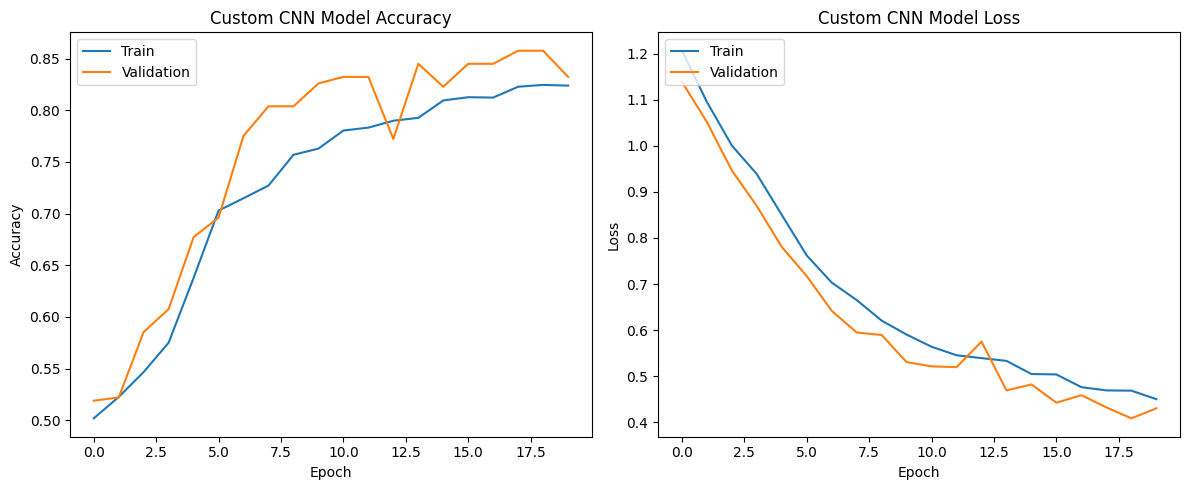

In [23]:
print("\nPlotting Training Curves for Custom CNN...")

plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Custom CNN Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Custom CNN Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()


Plotting Confusion Matrix for Custom CNN...


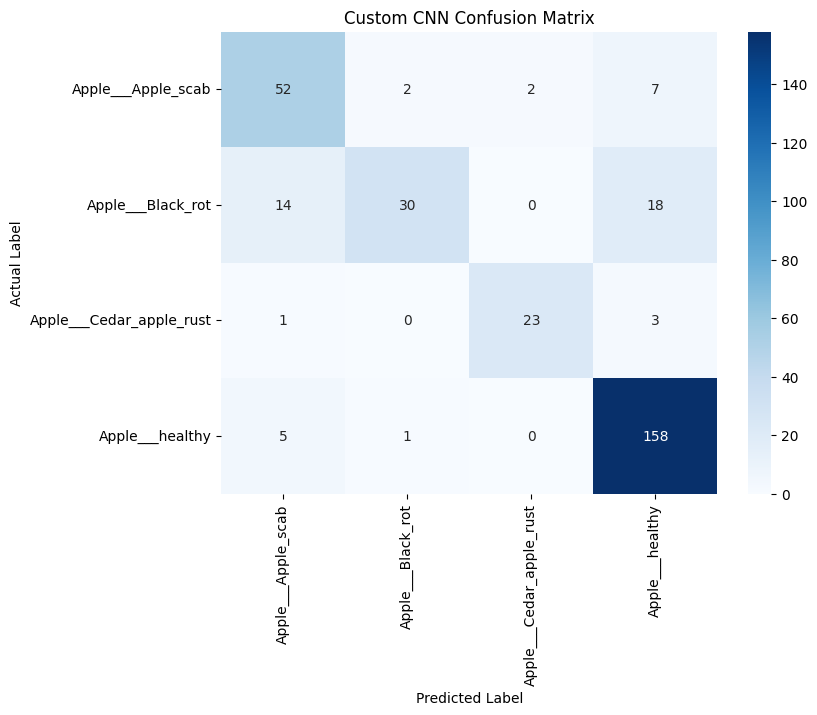

In [24]:
print("\nPlotting Confusion Matrix for Custom CNN...")

# Get class names from the generator
class_labels = list(train_generator.class_indices.keys())

# Generate confusion matrix
cm = confusion_matrix(val_labels, val_pred_labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Custom CNN Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()


Displaying Sample Predictions for Custom CNN...
Found 316 images belonging to 4 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 825ms/step


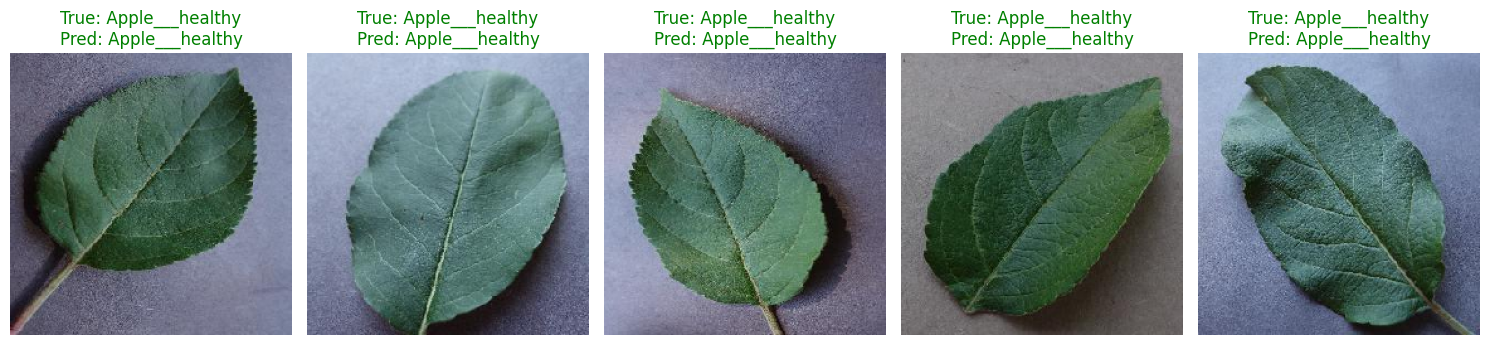

In [25]:
print("\nDisplaying Sample Predictions for Custom CNN...")

# Get class names from the generator
class_labels = list(train_generator.class_indices.keys())

# Create a small generator for sample images (optional, to ensure fresh batch)
sample_generator = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMAGE_SIZE,
    batch_size=5, # Get 5 samples
    class_mode="categorical",
    subset="validation",
    shuffle=True # Shuffle to get diverse samples
)

# Get a batch of images and their true labels
sample_images, sample_true_labels_one_hot = next(sample_generator)
sample_true_labels = np.argmax(sample_true_labels_one_hot, axis=1)

# Make predictions on the sample images
sample_pred_probs = custom_cnn.predict(sample_images)
sample_pred_labels = np.argmax(sample_pred_probs, axis=1)

plt.figure(figsize=(15, 8))
for i in range(len(sample_images)):
    plt.subplot(1, 5, i + 1) # Adjust subplot grid based on batch size
    plt.imshow(sample_images[i])
    true_label_name = class_labels[sample_true_labels[i]]
    pred_label_name = class_labels[sample_pred_labels[i]]
    title_color = "green" if true_label_name == pred_label_name else "red"
    plt.title(f"True: {true_label_name}\nPred: {pred_label_name}", color=title_color)
    plt.axis('off')
plt.tight_layout()
plt.show()

### 3.1 Load Pre-trained Model and Modify Architecture

In [66]:
print("\n" + "="*70)
print("TRANSFER LEARNING IMPLEMENTATION")


TRANSFER LEARNING IMPLEMENTATION


In [67]:
# TODO: Choose and load pre-trained model
pretrained_model_name = "ResNet50"

In [73]:
def build_transfer_learning_model(base_model_name, input_shape, n_classes, unfreeze_block=None):
    """
    Build transfer learning model with optional unfreezing of a specific block.

    Args:
        base_model_name: string (ResNet50)
        input_shape: tuple (height, width, channels)
        n_classes: number of output classes
        unfreeze_block: string, name of the block to unfreeze (e.g., 'conv5_block')

    Returns:
        model: compiled transfer learning model
    """
    if base_model_name == "ResNet50":
        base_model = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)
    else:
        raise ValueError("Unsupported base model.") # Extend for other models if needed

    # Freeze base layers by default
    for layer in base_model.layers:
        layer.trainable = False

    # Optionally unfreeze a specific block of layers
    if unfreeze_block:
        set_trainable = False
        for layer in base_model.layers:
            if unfreeze_block in layer.name:
                set_trainable = True
            if set_trainable:
                layer.trainable = True

    # Add custom classification head
    x = base_model.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(n_classes, activation='softmax')(x)

    model = models.Model(inputs=base_model.input, outputs=x)

    # Compile model
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])

    return model

In [74]:
# TODO: Create transfer learning model
unfreeze_block_name = "conv4_block"
transfer_model = build_transfer_learning_model(pretrained_model_name, image_shape, n_classes, unfreeze_block=unfreeze_block_name)

In [75]:
import tensorflow as tf

frozen_layers = 0
trainable_layers = 0
for layer in transfer_model.layers:
    if not layer.trainable:
        frozen_layers += 1
    else:
        trainable_layers += 1

total_parameters = transfer_model.count_params()
trainable_parameters = sum([tf.keras.backend.count_params(w) for w in transfer_model.trainable_weights])

In [76]:
print(f"Base Model: {pretrained_model_name}")
print(f"Frozen Layers: {frozen_layers}")
print(f"Trainable Layers: {trainable_layers}")
print(f"Total Parameters: {total_parameters:,}")
print(f"Trainable Parameters: {trainable_parameters:,}")
print(f"Using Global Average Pooling: YES")

Base Model: ResNet50
Frozen Layers: 81
Trainable Layers: 96
Total Parameters: 23,595,908
Trainable Parameters: 22,092,804
Using Global Average Pooling: YES


### 3.2 Train Transfer Learning Model

In [77]:
print("\nTraining Transfer Learning Model...")


Training Transfer Learning Model...


In [78]:
# Training configuration
tl_learning_rate = 0.00001
tl_epochs = 20
tl_batch_size = 64
tl_optimizer = "Adam"

In [79]:
# Track training time
tl_start_time = time.time()

In [80]:
# TODO: Train model
import math
steps_per_epoch_tl = math.ceil(train_generator.samples / tl_batch_size)
validation_steps_tl = math.ceil(val_generator.samples / tl_batch_size)
TLM_history = transfer_model.fit(
    train_generator,
    epochs=tl_epochs,
    steps_per_epoch=steps_per_epoch_tl,
    validation_data=val_generator,
    validation_steps=validation_steps_tl
)

Epoch 1/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 66s 775ms/step - accuracy: 0.6915 - loss: 0.7571 - val_accuracy: 0.0854 - val_loss: 1.8967
Epoch 2/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 16s 354ms/step - accuracy: 0.8924 - loss: 0.2926 - val_accuracy: 0.5190 - val_loss: 1.4087
Epoch 3/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 17s 366ms/step - accuracy: 0.9264 - loss: 0.2150 - val_accuracy: 0.5190 - val_loss: 2.8380
Epoch 4/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 18s 385ms/step - accuracy: 0.9552 - loss: 0.1126 - val_accuracy: 0.5190 - val_loss: 3.7216
Epoch 5/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 17s 379ms/step - accuracy: 0.9753 - loss: 0.0696 - val_accuracy: 0.5190 - val_loss: 3.5249
Epoch 6/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 20s 377ms/step - accuracy: 0.9816 - loss: 0.0524 - val_accuracy: 0.5190 - val_loss: 5.8987
Epoch 7/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 17s 365ms/step - accuracy: 0.9907 - loss: 0.0318 - val_accuracy: 0.6329 - val_loss: 2.3560
Epoch 8/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 17s 372ms/step - accuracy: 0.9824 - loss: 0.0440 - val_accu

In [81]:
tl_training_time = time.time() - tl_start_time

In [82]:
# REQUIRED: Track initial and final loss
tl_initial_loss = TLM_history.history['loss'][0]  # Get from training history (first epoch)
tl_final_loss = TLM_history.history['loss'][-1]  # Get from training history (last epoch)

In [83]:
print(f"Training completed in {tl_training_time:.2f} seconds")
print(f"Initial Loss: {tl_initial_loss:.4f}")
print(f"Final Loss: {tl_final_loss:.4f}")

Training completed in 399.40 seconds
Initial Loss: 0.5803
Final Loss: 0.0053


### 3.3 Evaluate Transfer Learning Model
- TODO: Make predictions on test set
- TODO: Calculate all 4 required metrics

In [86]:
# REQUIRED: Calculate all 4 metrics

# Make predictions on the validation data
val_labels = val_generator.classes
val_generator.reset()
tlm_val_pred_probs = transfer_model.predict(val_generator)
tlm_val_pred_labels = np.argmax(tlm_val_pred_probs, axis=1)

tl_accuracy = round(accuracy_score(val_labels, tlm_val_pred_labels), 4)
tl_precision = round(precision_score(val_labels, tlm_val_pred_labels, average='macro', zero_division=0), 4)
tl_recall = round(recall_score(val_labels, tlm_val_pred_labels, average='macro', zero_division=0), 4)
tl_f1 = round(f1_score(val_labels, tlm_val_pred_labels, average='macro', zero_division=0), 4)

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 259ms/step


In [87]:
print("\nTransfer Learning Performance:")
print(f"Accuracy:  {tl_accuracy:.4f}")
print(f"Precision: {tl_precision:.4f}")
print(f"Recall:    {tl_recall:.4f}")
print(f"F1-Score:  {tl_f1:.4f}")


Transfer Learning Performance:
Accuracy:  0.7215
Precision: 0.7448
Recall:    0.8376
F1-Score:  0.7382


### 3.4 Visualize Transfer Learning Results
- TODO: Plot training curves (loss and accuracy)
- TODO: Plot confusion matrix
- TODO: Show sample predictions

### 4.1 Metrics Comparison

In [88]:
comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Training Time (s)', 'Parameters'],
    'Custom CNN': [
        custom_cnn_accuracy,
        custom_cnn_precision,
        custom_cnn_recall,
        custom_cnn_f1,
        custom_cnn_training_time,
        custom_cnn.count_params()  # Filled with custom CNN total parameters
    ],
    'Transfer Learning': [
        tl_accuracy,
        tl_precision,
        tl_recall,
        tl_f1,
        tl_training_time,
        trainable_parameters
    ]
})

In [89]:
pd.set_option('display.float_format', '{:.4f}'.format)
print(comparison_df.to_string(index=False))

           Metric  Custom CNN  Transfer Learning
         Accuracy      0.8323             0.7215
        Precision      0.8502             0.7448
           Recall      0.7811             0.8376
         F1-Score      0.7974             0.7382
Training Time (s)    308.6330           399.4008
       Parameters  19652.0000      22092804.0000


### 4.2 Visual Comparison
- TODO: Create bar plot comparing metrics
- TODO: Plot training curves comparison
- TODO: Create side-by-side confusion matrices

In [43]:
analysis_text = """
TODO: Write your analysis here (maximum 200 words guideline)

Address:
1. Which model performed better and by how much?
   [Compare specific metrics]

2. Impact of pre-training vs training from scratch?
   [Discuss feature extraction, convergence speed]

3. Effect of Global Average Pooling?
   [Discuss parameter reduction, overfitting prevention]

4. Computational cost comparison?
   [Compare training time, total parameters]

5. Insights about transfer learning?
   [When to use transfer learning vs custom CNN]
"""

In [44]:
# REQUIRED: Print analysis with word count
print("ANALYSIS")
print(analysis_text)
print(f"Analysis word count: {len(analysis_text.split())} words")
if len(analysis_text.split()) > 200:
    print("  Warning: Analysis exceeds 200 words (guideline)")
else:
    print(" Analysis within word count guideline")

ANALYSIS

TODO: Write your analysis here (maximum 200 words guideline)

Address:
1. Which model performed better and by how much?
   [Compare specific metrics]

2. Impact of pre-training vs training from scratch?
   [Discuss feature extraction, convergence speed]

3. Effect of Global Average Pooling?
   [Discuss parameter reduction, overfitting prevention]

4. Computational cost comparison?
   [Compare training time, total parameters]

5. Insights about transfer learning?
   [When to use transfer learning vs custom CNN]

Analysis word count: 68 words
 Analysis within word count guideline


In [45]:
def get_assignment_results():
    """
    Generate complete assignment results in required format

    Returns:
        dict: Complete results with all required fields
    """

    framework_used = "keras"  # TODO: Change to "pytorch" if using PyTorch

    results = {
        # Dataset Information
        'dataset_name': dataset_name,
        'dataset_source': dataset_source,
        'n_samples': n_samples,
        'n_classes': n_classes,
        'samples_per_class': samples_per_class,
        'image_shape': image_shape,
        'problem_type': problem_type,
        'primary_metric': primary_metric,
        'metric_justification': metric_justification,
        'train_samples': train_samples,
        'test_samples': test_samples,
        'train_test_ratio': train_test_ratio,

        # Custom CNN Results
        'custom_cnn': {
            'framework': framework_used,
            'architecture': {
                'conv_layers': 0,  # TODO: Count your conv layers
                'pooling_layers': 0,  # TODO: Count your pooling layers
                'has_global_average_pooling': True,  # MUST be True
                'output_layer': 'softmax',
                'total_parameters': 0  # TODO: Calculate total parameters
            },
            'training_config': {
                'learning_rate': 0.001,  # TODO: Your actual learning rate
                'n_epochs': 20,  # TODO: Your actual epochs
                'batch_size': 32,  # TODO: Your actual batch size
                'optimizer': 'Adam',  # TODO: Your actual optimizer
                'loss_function': 'categorical_crossentropy'  # TODO: Your actual loss
            },
            'initial_loss': custom_cnn_initial_loss,
            'final_loss': custom_cnn_final_loss,
            'training_time_seconds': custom_cnn_training_time,
            'accuracy': custom_cnn_accuracy,
            'precision': custom_cnn_precision,
            'recall': custom_cnn_recall,
            'f1_score': custom_cnn_f1
        },

        # Transfer Learning Results
        'transfer_learning': {
            'framework': framework_used,
            'base_model': pretrained_model_name,
            'frozen_layers': frozen_layers,
            'trainable_layers': trainable_layers,
            'has_global_average_pooling': True,  # MUST be True
            'total_parameters': total_parameters,
            'trainable_parameters': trainable_parameters,
            'training_config': {
                'learning_rate': tl_learning_rate,
                'n_epochs': tl_epochs,
                'batch_size': tl_batch_size,
                'optimizer': tl_optimizer,
                'loss_function': 'categorical_crossentropy'
            },
            'initial_loss': tl_initial_loss,
            'final_loss': tl_final_loss,
            'training_time_seconds': tl_training_time,
            'accuracy': tl_accuracy,
            'precision': tl_precision,
            'recall': tl_recall,
            'f1_score': tl_f1
        },

        # Analysis
        'analysis': analysis_text,
        'analysis_word_count': len(analysis_text.split()),

        # Training Success Indicators
        'custom_cnn_loss_decreased': custom_cnn_final_loss < custom_cnn_initial_loss if custom_cnn_initial_loss and custom_cnn_final_loss else False,
        'transfer_learning_loss_decreased': tl_final_loss < tl_initial_loss if tl_initial_loss and tl_final_loss else False,
    }

    return results

In [46]:
# Generate and print results
try:
    assignment_results = get_assignment_results()
    print("ASSIGNMENT RESULTS SUMMARY")
    print(json.dumps(assignment_results, indent=2))

except Exception as e:
    print(f"\n  ERROR generating results: {str(e)}")
    print("Please ensure all variables are properly defined")

ASSIGNMENT RESULTS SUMMARY

  ERROR generating results: Object of type int64 is not JSON serializable
Please ensure all variables are properly defined


In [47]:
# Display system information
import platform
import sys
from datetime import datetime

In [48]:
print("ENVIRONMENT INFORMATION")
print("\n  REQUIRED: Add screenshot of your Google Colab/BITS Virtual Lab")
print("showing your account details in the cell below this one.")

# include the screen shot here

ENVIRONMENT INFORMATION

  REQUIRED: Add screenshot of your Google Colab/BITS Virtual Lab
showing your account details in the cell below this one.


# Task
To enhance the transfer learning model, I will first adjust the `tl_learning_rate` to `5e-6` and increase `tl_epochs` to 50. After updating these hyperparameters, I will re-train the transfer learning model, evaluate its performance by calculating accuracy, precision, recall, and F1-score, and then update the comparison table. Finally, I will analyze if the enhanced model achieves an accuracy above 95% and summarize the impact of these hyperparameter changes.

## Adjust Fine-tuning Hyperparameters

### Subtask:
Modify the `tl_learning_rate` to an even smaller value (e.g., `5e-6`) and increase the `tl_epochs` (e.g., to 50) in the training configuration cell for the transfer learning model. This allows for more precise adjustments over a longer period.


**Reasoning**:
The user wants to modify the `tl_learning_rate` and `tl_epochs` variables in the training configuration for the transfer learning model to fine-tune the training process. I will update these values in the existing code cell.



In [1]:
tl_learning_rate = 0.000005
tl_epochs = 50
tl_batch_size = 64
tl_optimizer = "Adam"

**Reasoning**:
The hyperparameters for the transfer learning model have been updated. The next logical step is to re-train the transfer learning model with these new hyperparameters, as specified in the main task description.



In [2]:
import math
steps_per_epoch_tl = math.ceil(train_generator.samples / tl_batch_size)
validation_steps_tl = math.ceil(val_generator.samples / tl_batch_size)
TLM_history = transfer_model.fit(
    train_generator,
    epochs=tl_epochs,
    steps_per_epoch=steps_per_epoch_tl,
    validation_data=val_generator,
    validation_steps=validation_steps_tl
)

NameError: name 'train_generator' is not defined